# Black–Litterman Model — Equilibrium Prior

This notebook implements the **first step of the Black–Litterman (BL) framework**:  
the construction of *implied equilibrium expected returns*.

The Black–Litterman model addresses a key weakness of classical mean–variance
optimization: extreme sensitivity to expected return estimates. Rather than
starting from subjective or noisy forecasts, BL begins with a **neutral prior**
derived from the market portfolio.

### Core idea
If the market portfolio is assumed to be mean–variance optimal, then there
exists a vector of expected returns that makes this portfolio optimal under
standard Markowitz theory. These returns are called **implied equilibrium
returns**.

Mathematically:

$[
\pi = \lambda \Sigma w_{mkt}
$]

where:
- ( $π $) is the vector of implied equilibrium excess returns  
- \( $\Sigma $) is the asset return covariance matrix  
- \( $w_{mkt}$ \) are market (or proxy) portfolio weights  
- \( $\lambda$ \) is the risk aversion parameter  

These equilibrium returns serve as the **prior** in the BL framework.  
In later steps, subjective views will be incorporated in a disciplined Bayesian
manner to form posterior expected returns.

### Scope of this notebook
This notebook focuses **only** on:
- loading price data  
- estimating the covariance matrix  
- defining market weights  
- computing implied equilibrium returns  

No investor views, Bayesian updates, or portfolio optimization are performed
here. Those will be handled in subsequent notebooks.

The goal is clarity, correctness, and reproducibility.


/tmp/ipython-input-2910676584.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  5 of 5 completed


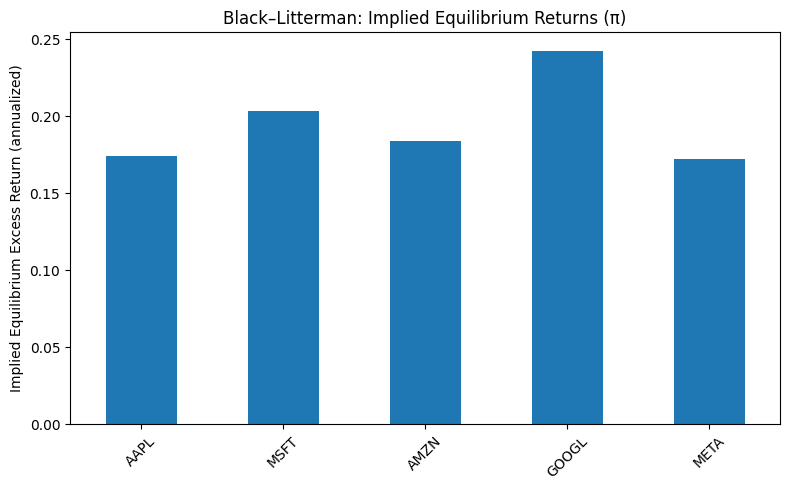

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

plt.style.use("default")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

# Universe of assets (you can adjust this)
tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "META"]

n_assets = len(tickers)

# For now, use equal weights as a proxy for market portfolio
# You can later replace this with market-cap weights.
w_mkt = np.ones(n_assets) / n_assets

w_mkt
start_date = "2018-01-01"
end_date = None  # uses latest available

data = yf.download(tickers, start=start_date, end=end_date)

# Use 'Adj Close' for stability; you can switch to 'Close' if you want consistency with other notebooks
prices = data["Close"].dropna(how="all")

prices.tail()

# Log returns
returns = np.log(prices / prices.shift(1)).dropna()

# Daily covariance
cov_daily = returns.cov()

# Annualized covariance matrix Σ
trading_days = 252
cov_annual = cov_daily * trading_days

cov_annual
# Risk aversion parameter (λ)
# Common example values are between 2 and 4 in many BL demos.
lam = 2.5

lam
# Ensure correct alignment between cov_annual and weights
cov_matrix = cov_annual.values  # (n_assets x n_assets)
w_vec = w_mkt.reshape(-1, 1)    # (n_assets x 1)

# π = λ Σ w_mkt
pi = lam * cov_matrix @ w_vec   # (n_assets x 1)

# Convert to a pandas Series indexed by tickers
pi_series = pd.Series(pi.flatten(), index=tickers, name="Implied Equilibrium Return")

pi_series
pi_series.describe()

plt.figure(figsize=(8, 5))
pi_series.plot(kind="bar")
plt.ylabel("Implied Equilibrium Excess Return (annualized)")
plt.title("Black–Litterman: Implied Equilibrium Returns (π)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## What this notebook is doing (Black–Litterman: Equilibrium Prior)

This notebook builds the **prior** for the Black–Litterman model.

1. **Select assets and define a market portfolio**
   - Choose a small universe of liquid stocks (e.g., AAPL, MSFT, AMZN, GOOGL, META).
   - Assign “market” weights (here: equal weights as a simple proxy).
   - These weights represent the portfolio we treat as **currently optimal**.

2. **Download historical price data**
   - Pull daily Adjusted Close prices with `yfinance`.
   - Clean the data and align all series on the same dates.

3. **Compute returns and the covariance matrix Σ**
   - Convert prices to daily log returns.
   - Estimate the sample covariance matrix of returns.
   - Annualize the covariance by multiplying by 252 (trading days).

4. **Set a risk aversion parameter λ**
   - Choose a scalar λ (e.g., 2.5) that controls how much the investor dislikes risk.
   - This is not calibrated here; it is a reasonable example value for illustration.

5. **Compute implied equilibrium returns π**
   - Use the Black–Litterman equilibrium relation:
     \[
     \pi = \lambda \Sigma w_{mkt}
     \]
   - This gives a vector of **implied equilibrium excess returns**.
   - These are the returns that make the chosen market portfolio optimal under mean–variance theory.

6. **Visualize π**
   - Plot a bar chart of the implied equilibrium returns for each asset.
   - This helps check relative magnitudes and confirm the implementation is behaving sensibly.

**Key point:**  
The returns computed here are **not forecasts**. They are a *neutral, model-consistent prior* that will later be combined with investor views in the full Black–Litterman framework.
